<a href="https://colab.research.google.com/github/yudhistira24ti/statistika-deskriptif-p4/blob/main/Tugas_Probalitas_Dan_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving yudhis.xlsx to yudhis (1).xlsx


In [28]:
dataraw = pd.read_excel("yudhis.xlsx")

dataraw = dataraw.drop(columns=["Unnamed: 0"], errors="ignore")
dataraw.columns = ["NIM", "Name", "KUIS", "UTS", "UAS", "Nilai", "Grade"]

dataraw = dataraw[pd.to_numeric(dataraw["NIM"], errors="coerce").notna()].reset_index(drop=True)
print(dataraw)
print("Jumlah mahasiswa:", len(dataraw))

datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
print(datafrq)

datafrq["Persentase (%)"] = (datafrq["Frekuensi"] / datafrq["Frekuensi"].sum() * 100).round(1)
print(datafrq)

       NIM                Name KUIS   UTS UAS  Nilai Grade
0   120001            John Doe   85  78.0  90  84.44     A
1   120005          Jane Smith   92  88.0  94  91.38     A
2   120017     Michael Johnson   48  65.0  56  56.41     C
3   120018         Emily Brown   90  85.0  88  87.65     A
4   120022     Daniel Martinez   75  80.0  77  77.35    AB
5   120024        Sarah Wilson   88  70.0  65  74.01     B
6   120025        David Garcia   75  70.0  75  73.35     B
7   120027         Jessica Lee   95  91.0  96  94.03     A
8   120034       Matthew Davis   79  84.0  78   80.3    AB
9   120035  Jennifer Rodriguez   42  48.0  63  51.33     C
10  120036       Andrew Taylor   53  64.0  59  58.73     C
11  120038    Amanda Hernandez   91  95.0  90  91.97     A
12  120039   Christopher Clark   76  81.0  75   77.3    AB
13  120046  Elizabeth Martinez   89  93.0  88  89.97     A
14  120047    William Anderson   80  85.0  79   81.3     A
15  120049       Sophia Thomas   94  90.0  95  93.03    

<Axes: title={'center': 'Grafik Garis'}, xlabel='Grade'>

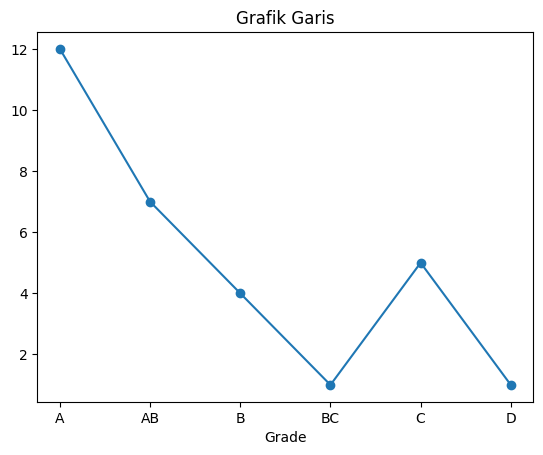

In [25]:
datafrq["Frekuensi"].plot(title="Grafik Garis", marker="o")

<Axes: title={'center': 'Grafik Batang'}, xlabel='Grade'>

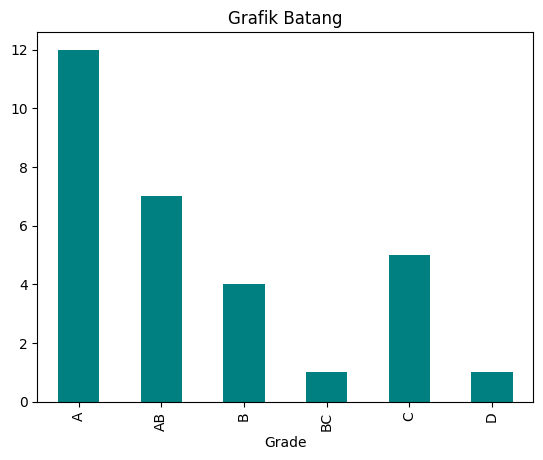

In [26]:
datafrq["Frekuensi"].plot(kind="bar", color="teal", title="Grafik Batang")

<Axes: title={'center': 'Pie Chart'}, ylabel='Frekuensi'>

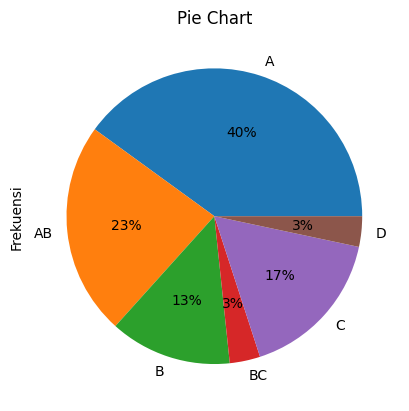

In [27]:
datafrq["Frekuensi"].plot(kind="pie", autopct="%1.0f%%", title="Pie Chart")

In [23]:
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]
stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()

q1, q3 = dt.quantile(0.25), dt.quantile(0.75)
iqr = q3 - q1
stats["IQR"] = iqr
stats["Batas bawah"] = q1 - 1.5 * iqr
stats["Batas atas"] = q3 + 1.5 * iqr
stats["Jumlah outlier"] = ((dt < q1 - 1.5*iqr) | (dt > q3 + 1.5*iqr)).sum()
stats["CV (%)"] = dt.std() / dt.mean() * 100
print(stats.round(3))

count              30.000
mean               76.221
std                13.467
min                46.010
25%                68.095
50%                78.800
75%                87.040
max                94.030
Standard Error      2.459
Median             78.800
Mode               77.300
variance          181.349
range              48.020
skewness           -0.664
kurtosis           -0.527
IQR                18.945
Batas bawah        39.677
Batas atas        115.458
Jumlah outlier      0.000
CV (%)             17.668
Name: Nilai, dtype: float64


In [24]:
with pd.ExcelWriter("hasil_yudhis.xlsx") as w:
    datafrq.to_excel(w, sheet_name="Frekuensi")
    stats.round(3).to_frame("Nilai").to_excel(w, sheet_name="Statistik")
files.download("hasil_yudhis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>